In [ ]:
# ===========================================================================
# FASE 0: CONEXIÓN CLOUD SEGURA E INGENIERÍA DE CARACTERÍSTICAS INTEGRADA
# ===========================================================================

import os
from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import col, when 

ruta_notebook_actual = os.getcwd()
ruta_raiz = os.path.dirname(ruta_notebook_actual)
ruta_al_env = os.path.join(ruta_raiz, "src", ".env")

load_dotenv(dotenv_path=ruta_al_env)
MONGO_URI = os.getenv("MONGO_URI")

if MONGO_URI is None:
    raise ValueError(f"❌ ERROR CRÍTICO: No se encontró el archivo .env en: {ruta_al_env}")
else:
    print("✅ ¡Seguridad Certificada! Conexión extraída de manera segura desde las variables de entorno.")

spark = SparkSession.builder \
    .appName("AveMayo_Modelado_No_Supervisado") \
    .config("spark.mongodb.read.connection.uri", MONGO_URI) \
    .config("spark.mongodb.write.connection.uri", MONGO_URI) \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.4.0") \
    .master("local[*]") \
    .getOrCreate()

df_raw_model = spark.read.format("mongodb") \
    .option("database", "Canasta_db") \
    .option("collection", "processed_data") \
    .load()

# ---------------------------------------------------------------------------
# RECONSTRUCCIÓN DEL FLUJO UNIFICADO (Sincronización con el EDA)
# ---------------------------------------------------------------------------
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

df_preparado = df_raw_model.withColumn(
    "tipo_producto",
    when(col("categoria").contains("arroz") | col("categoria").contains("fideos") | col("categoria").contains("legumbres") | col("categoria").contains("harina"), "Abarrotes")
    .when(col("categoria").contains("aceite") | col("categoria").contains("mantequilla") | col("categoria").contains("grasa"), "Grasas y Aceites")
    .when(col("categoria").contains("leche") | col("categoria").contains("queso") | col("categoria").contains("yogurt"), "Lácteos")
    .when(col("categoria").contains("limpieza") | col("categoria").contains("detergente") | col("categoria").contains("lavaloza"), "Limpieza e Higiene")
    .otherwise("Otros Alimentos")
)

indexer_marca = StringIndexer(inputCol="marca", outputCol="marca_cat", handleInvalid="keep")
indexer_tipo = StringIndexer(inputCol="tipo_producto", outputCol="tipo_producto_cat", handleInvalid="keep")

pipeline_prep = Pipeline(stages=[indexer_marca, indexer_tipo])
df_final_preparado = pipeline_prep.fit(df_preparado).transform(df_preparado) \
    .withColumn("marca_cat", col("marca_cat").cast("int")) \
    .withColumn("tipo_producto_cat", col("tipo_producto_cat").cast("int"))

# ---------------------------------------------------------------------------
# VECTORIZACIÓN Y ESCALAMIENTO CIENTÍFICO (Preparación K-Means/DBSCAN)
# ---------------------------------------------------------------------------
features_input = ["precio_redondeado", "dif_porcentual_promedio", "marca_cat", "tipo_producto_cat"]

assembler = VectorAssembler(
    inputCols=features_input, 
    outputCol="features",
    handleInvalid="skip"
)
df_vector = assembler.transform(df_final_preparado)

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=False)
scaler_model = scaler.fit(df_vector)
df_scaled_final = scaler_model.transform(df_vector)

print("\n¡Fase de Inicialización completada con éxito!")
print(f"DataFrame unificado con el EDA listo para Clustering: 'scaledFeatures'")

✅ ¡Seguridad Certificada! Conexión extraída de manera segura desde las variables de entorno.

¡Fase de Inicialización completada con éxito!
DataFrame unificado con el EDA listo para Clustering: 'scaledFeatures'


In [3]:
# ===========================================================================
# FASE 1: EXPERIMENTACIÓN CON ALGORITMOS BASADOS EN DENSIDAD (DBSCAN)
# ===========================================================================

from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

print("Extraendo variables y ejecutando DBSCAN...")

pdf_dbscan = df_scaled_final.select(
    "scaledFeatures", 
    "marca", 
    "precio_redondeado", 
    "dif_porcentual_promedio"
).toPandas()

X = np.array(pdf_dbscan['scaledFeatures'].apply(lambda x: x.toArray()).tolist())

dbscan = DBSCAN(eps=0.6, min_samples=5)
pdf_dbscan['cluster_dbscan'] = dbscan.fit_predict(X)

print(f"✅ DBSCAN ejecutado. Registros procesados: {len(pdf_dbscan)}")

Extraendo variables y ejecutando DBSCAN...
✅ DBSCAN ejecutado. Registros procesados: 6174


📊 Renderizando mapa de dispersión multivariado de DBSCAN...


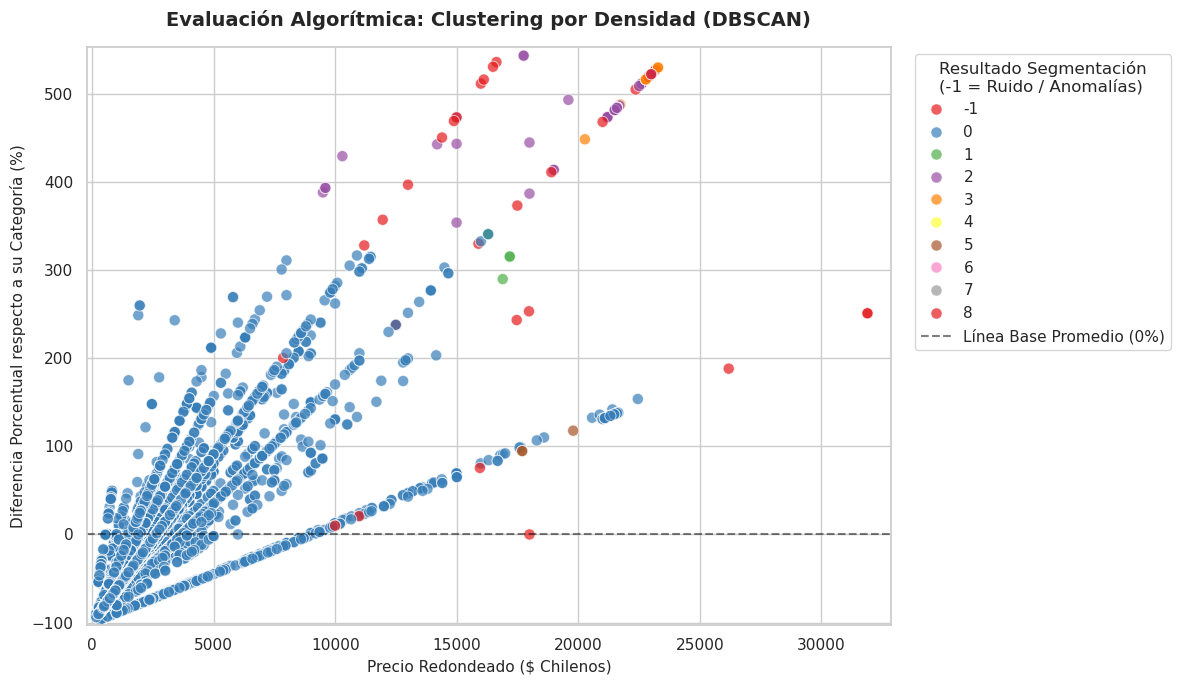

In [4]:
# ===========================================================================
# FASE 2: VISUALIZACIÓN DE COMPORTAMIENTO DE DENSIDAD (DBSCAN DESCARTE)
# ===========================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.evaluation import ClusteringEvaluator

print("📊 Renderizando mapa de dispersión multivariado de DBSCAN...")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

p_min, p_max = np.percentile(pdf_dbscan['precio_redondeado'], [1, 99])
d_min, d_max = np.percentile(pdf_dbscan['dif_porcentual_promedio'], [1, 99])

sns.scatterplot(
    data=pdf_dbscan,
    x='precio_redondeado',
    y='dif_porcentual_promedio',
    hue='cluster_dbscan',
    palette='Set1',        
    s=65,                  
    alpha=0.7
)

plt.xlim(p_min - 500, p_max + 1000)
plt.ylim(d_min - 10, d_max + 10)

plt.title('Evaluación Algorítmica: Clustering por Densidad (DBSCAN)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Precio Redondeado ($ Chilenos)', fontsize=11)
plt.ylabel('Diferencia Porcentual respecto a su Categoría (%)', fontsize=11)
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Línea Base Promedio (0%)')

plt.legend(title='Resultado Segmentación\n(-1 = Ruido / Anomalías)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Iniciando cómputo distribuido y evaluación multicriterio en Spark...
📊 Analizando coeficientes (K=2 a K=12)... Esto tomará un momento.

=== MÉTRICAS METODOLÓGICAS PARA EL REPORTE AVE MAYO ===
 K (Clusters)  Costo (Inercia)  Silueta
            2         10933.25   0.9338
            3          6466.08   0.8007
            4          5116.85   0.8061
            5          4613.24   0.8071
            6          3784.41   0.6951
            7          3073.80   0.5657
            8          2895.70   0.5600
            9          2348.30   0.5653
           10          2192.51   0.5673
           11          1855.51   0.5818
           12          1992.45   0.5730
TIP: Seleccionen el K donde el Costo se estabilice y la Silueta alcance su máximo local.



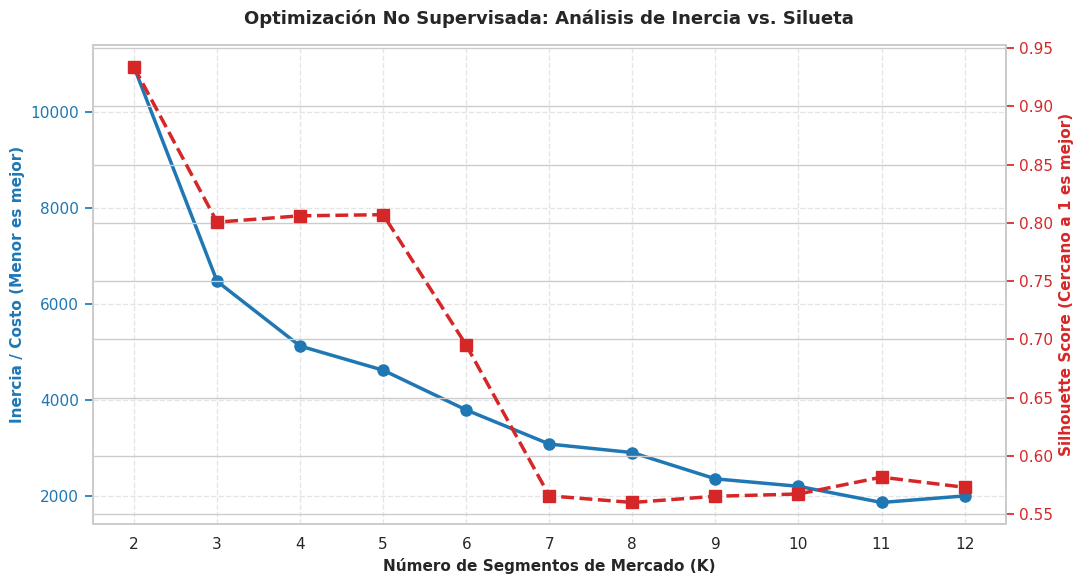

In [5]:
# ===========================================================================
# FASE 3: OPTIMIZACIÓN MATEMÁTICA MULTICRITERIO (INERCIA Y SILUETA)
# ===========================================================================

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import pandas as pd

print("Iniciando cómputo distribuido y evaluación multicriterio en Spark...")
print("📊 Analizando coeficientes (K=2 a K=12)... Esto tomará un momento.")

resultados = []
cost = []
siluetas = []
rango_k = range(2, 13)

evaluator = ClusteringEvaluator(
    predictionCol="prediction", 
    featuresCol="scaledFeatures", 
    metricName="silhouette", 
    distanceMeasure="squaredEuclidean"
)

for k in rango_k:
    kmeans = KMeans(featuresCol='scaledFeatures', k=k, seed=42)
    model = kmeans.fit(df_scaled_final)

    inercia = model.summary.trainingCost
    cost.append(inercia)

    predicciones = model.transform(df_scaled_final)
    silhouette = evaluator.evaluate(predicciones)
    siluetas.append(silhouette)

    resultados.append({
        "K (Clusters)": k, 
        "Costo (Inercia)": round(inercia, 2), 
        "Silueta": round(silhouette, 4)
    })

df_resultados = pd.DataFrame(resultados)
print("\n=== MÉTRICAS METODOLÓGICAS PARA EL REPORTE AVE MAYO ===")
print(df_resultados.to_string(index=False))
print("==========================================================")
print("TIP: Seleccionen el K donde el Costo se estabilice y la Silueta alcance su máximo local.\n")

fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(rango_k, cost, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=8)
ax1.set_xlabel('Número de Segmentos de Mercado (K)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Inercia / Costo (Menor es mejor)', color='#1f77b4', fontsize=11, fontweight='bold')
ax1.tick_params('y', colors='#1f77b4')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(rango_k, siluetas, marker='s', linestyle='--', color='#d62728', linewidth=2.5, markersize=8)
ax2.set_ylabel('Silhouette Score (Cercano a 1 es mejor)', color='#d62728', fontsize=11, fontweight='bold')
ax2.tick_params('y', colors='#d62728')

plt.title('Optimización No Supervisada: Análisis de Inercia vs. Silueta', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rango_k)
fig.tight_layout()
plt.show()

In [6]:
# ===========================================================================
# FASE 4: ENTRENAMIENTO DEFINITIVO Y PERSISTENCIA DEL MODELO K-MEANS
# ===========================================================================

import os
from pyspark.ml.clustering import KMeans

k_optimo = 3

print(f"🎯 Entrenando el modelo final de K-Means con K={k_optimo} segmentos estratégicos...")

kmeans_final = KMeans(featuresCol='scaledFeatures', k=k_optimo, seed=42)
model_final = kmeans_final.fit(df_scaled_final)

df_clusters = model_final.transform(df_scaled_final)

print(f"\n📊 Vista previa de la Canasta Básica Etiquetada (K={k_optimo}):")
df_clusters.select(
    "nombre_producto", 
    "precio_redondeado",
    "dif_porcentual_promedio", 
    "prediction"
).show(15, truncate=False)

ruta_base_modelos = os.path.join(os.getcwd(), "modelos_output")

ruta_datos = os.path.join(ruta_base_modelos, "datos_etiquetados_kmeans")
ruta_modelo = os.path.join(ruta_base_modelos, "kmeans_modelo_v1")

print("\nExportando artefactos de Machine Learning a disco de forma portable...")

df_clusters.write.mode("overwrite").parquet(ruta_datos)
model_final.write().overwrite().save(ruta_modelo)

print("============ 🚀 HITOS DE MODELADO COMPLETADO PRO EN APARK ============")
print(f"✔️ Datos indexados con clúster guardados en: {ruta_datos}")
print(f"✔️ Objeto del modelo KMeans serializado en: {ruta_modelo}")
print("=====================================================================")

🎯 Entrenando el modelo final de K-Means con K=3 segmentos estratégicos...

📊 Vista previa de la Canasta Básica Etiquetada (K=3):
+--------------------------------------------------+-----------------+-----------------------+----------+
|nombre_producto                                   |precio_redondeado|dif_porcentual_promedio|prediction|
+--------------------------------------------------+-----------------+-----------------------+----------+
|Pechuga Pavo Ahumada 125 g Sopraval               |2150.0           |-48.01                 |2         |
|Paté de Pollo 125 g Pf                            |590.0            |-85.73                 |0         |
|Pizza Pollo Champiñon 1 Un Acuenta                |2890.0           |-30.12                 |0         |
|Pechuga de Pavo Cocida Corte Pluma 125 g La Pre...|2890.0           |-30.12                 |0         |
|Pechuga de Pavo ahumada corte pluma 125 g La Pr...|2850.0           |-31.09                 |0         |
|Pasta Pollo Ciboulette

📊 Extrayendo datos y renderizando el gráfico analítico final...


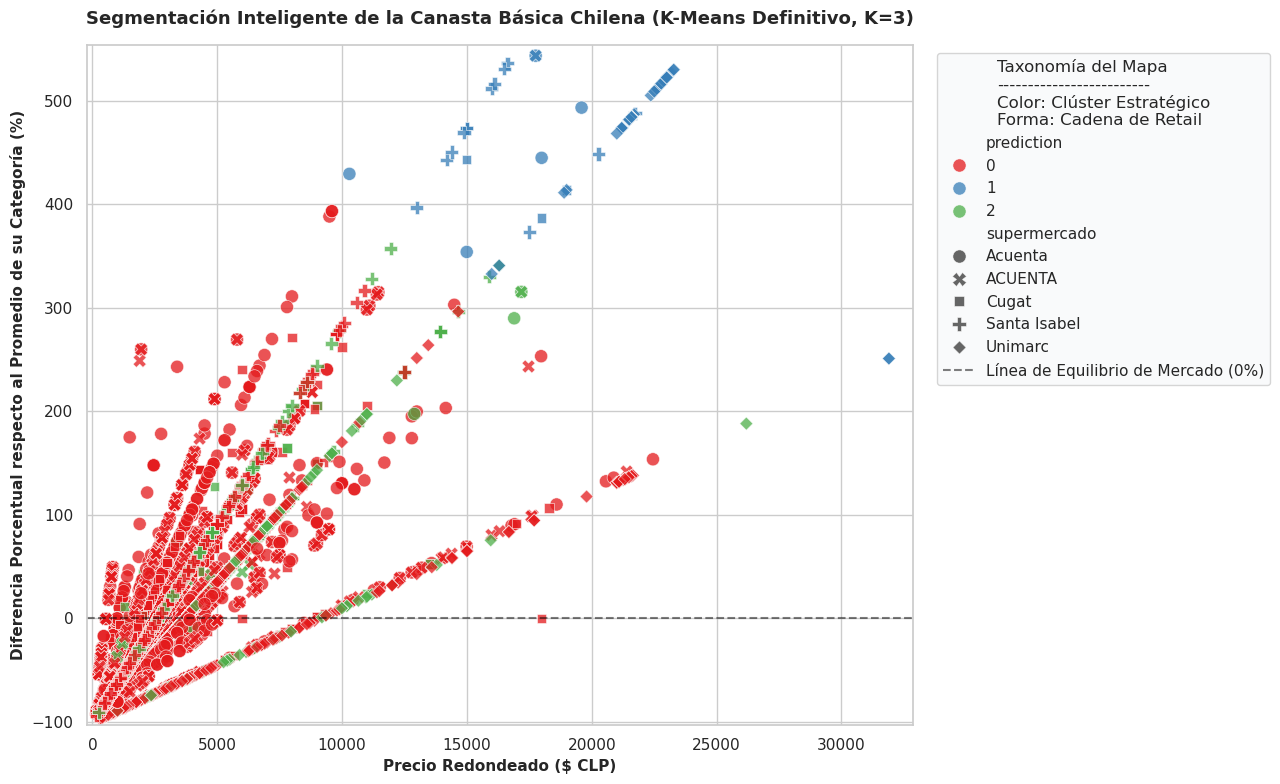

In [7]:
# ===========================================================================
# FASE 5: PERFILAMIENTO INDUSTRIAL Y VISUALIZACIÓN ESTRATÉGICA DE MERCADO
# ===========================================================================

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

print("📊 Extrayendo datos y renderizando el gráfico analítico final...")

pdf_visual = df_clusters.select(
    "precio_redondeado",       
    "dif_porcentual_promedio", 
    "prediction", 
    "supermercado"
).toPandas()

p_min, p_max = np.percentile(pdf_visual['precio_redondeado'].dropna(), [1, 99])
d_min, d_max = np.percentile(pdf_visual['dif_porcentual_promedio'].dropna(), [1, 99])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=pdf_visual,
    x='precio_redondeado',          
    y='dif_porcentual_promedio',    
    hue='prediction',               
    style='supermercado',          
    palette='Set1',                
    s=90,                           
    alpha=0.75,                     
    edgecolor='w',
    linewidth=0.5
)

plt.xlim(p_min - 500, p_max + 1000)
plt.ylim(d_min - 10, d_max + 10)

plt.title(f'Segmentación Inteligente de la Canasta Básica Chilena (K-Means Definitivo, K={k_optimo})', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Precio Redondeado ($ CLP)', fontsize=11, fontweight='bold')
plt.ylabel('Diferencia Porcentual respecto al Promedio de su Categoría (%)', fontsize=11, fontweight='bold')

plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Línea de Equilibrio de Mercado (0%)')

plt.legend(
    title='Taxonomía del Mapa\n-------------------------\nColor: Clúster Estratégico\nForma: Cadena de Retail',
    bbox_to_anchor=(1.02, 1), 
    loc='upper left',
    frameon=True,
    shadow=False,
    facecolor='#f8f9fa'
)

plt.tight_layout()
plt.show()